# 05 Question 5: ODE Model Versus ML/Regression Approaches

This notebook answers Q5: how do the mechanistic p53 ODE model results compare with the regression-based transfer analyses from Q3 and Q4?

The goal is synthesis, not new model building. We load the saved Q1-Q4 result tables and place the results side by side.

## Conceptual Comparison

The p53 ODE model is mechanistic and interpretable. It uses the given course template to simulate p53 DNA-damage response behaviour, then tests the resulting p53 S15/S46 response summaries against survival or drug response.

The PRISM elastic-net signature is data-driven. It learns gene coefficients from breast cancer cell-line baseline expression and measured PRISM doxorubicin sensitivity.

The TCGA Cox score is patient-derived and prognostic. It learns a survival-risk score from TCGA-BRCA tumour expression and overall survival.

These approaches answer related but different questions. TCGA overall survival and PRISM doxorubicin sensitivity are not the same endpoint, so transfer in either direction should be interpreted cautiously.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import spearmanr
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

tables_dir = project_root / "tables"
figures_dir = project_root / "figures"
figures_dir.mkdir(exist_ok=True)
tables_dir.mkdir(exist_ok=True)

q1_path = tables_dir / "q1_p53_ode_tcga_survival_results.csv"
q2_path = tables_dir / "q2_p53_ode_prism_correlation_results.csv"
q3_survival_path = tables_dir / "q3_prism_signature_tcga_survival_results.csv"
q3_cv_path = tables_dir / "q3_prism_signature_cross_validation_results.csv"
q3_coefficients_path = tables_dir / "prism_doxorubicin_signature_coefficients.csv"
q4_survival_path = tables_dir / "q4_tcga_survival_score_results.csv"
q4_prism_path = tables_dir / "q4_tcga_score_prism_correlation_results.csv"
prism_table_path = project_root / "data/processed/brca_prism_doxorubicin_modelling_table.csv"

summary_path = tables_dir / "q5_model_comparison_summary.csv"
figure_path = figures_dir / "q5_model_comparison_summary.png"

required_paths = [
    q1_path, q2_path, q3_survival_path, q3_cv_path, q3_coefficients_path,
    q4_survival_path, q4_prism_path, prism_table_path,
]
missing_paths = [path for path in required_paths if not path.exists()]
if missing_paths:
    raise FileNotFoundError("Missing required Q1-Q4 result files: " + ", ".join(str(path) for path in missing_paths))

## Load Existing Q1-Q4 Results

The table below loads the saved results created by the previous notebooks. The Q3 apparent in-sample metrics were not saved as a separate table, so they are reconstructed from the saved Q3 coefficient table and the same processed PRISM modelling table. This does not refit or tune the Q3 model.

In [2]:
q1 = pd.read_csv(q1_path)
q2 = pd.read_csv(q2_path)
q3_survival = pd.read_csv(q3_survival_path)
q3_cv = pd.read_csv(q3_cv_path)
q3_coefficients = pd.read_csv(q3_coefficients_path)
q4_survival = pd.read_csv(q4_survival_path)
q4_prism = pd.read_csv(q4_prism_path)
prism = pd.read_csv(prism_table_path)

print("Q1 rows:", len(q1))
print("Q2 rows:", len(q2))
print("Q3 survival rows:", len(q3_survival))
print("Q3 CV rows:", len(q3_cv))
print("Q4 survival rows:", len(q4_survival))
print("Q4 PRISM rows:", len(q4_prism))

Q1 rows: 10
Q2 rows: 16
Q3 survival rows: 4
Q3 CV rows: 7
Q4 survival rows: 4
Q4 PRISM rows: 2


In [3]:
# Q1: pre-specified p53 ODE S46 AUC feature against TCGA survival.
q1_main = q1[
    (q1["analysis"] == "univariate_cox_per_1_sd")
    & (q1["feature"] == "p53_S46_AUC_across_DDR")
].iloc[0]

q1_age = q1[
    (q1["analysis"] == "age_adjusted_cox_main_feature_per_1_sd")
    & (q1["feature"] == "p53_S46_AUC_across_DDR")
].iloc[0]

# Q2: same p53 ODE feature against PRISM doxorubicin sensitivity.
q2_spearman = q2[
    (q2["feature"] == "p53_S46_AUC_across_DDR")
    & (q2["method"] == "spearman")
].iloc[0]

q2_pearson = q2[
    (q2["feature"] == "p53_S46_AUC_across_DDR")
    & (q2["method"] == "pearson")
].iloc[0]

# Q3: apparent in-sample metrics from saved coefficients, without refitting the model.
q3_genes = q3_coefficients["gene"].tolist()
X_prism = prism[q3_genes].astype(float)
y_prism = prism["doxorubicin_sensitivity_score"].astype(float)
X_prism_scaled = StandardScaler().fit_transform(X_prism)
q3_apparent_prediction = X_prism_scaled @ q3_coefficients["coefficient"].to_numpy() + q3_coefficients["model_intercept"].iloc[0]

q3_apparent_r2 = r2_score(y_prism, q3_apparent_prediction)
q3_apparent_rmse = np.sqrt(mean_squared_error(y_prism, q3_apparent_prediction))
q3_apparent_spearman_r, q3_apparent_spearman_p = spearmanr(y_prism, q3_apparent_prediction)

# Q3 cross-validation metrics.
q3_cv_values = q3_cv.set_index("metric")["value"]
q3_cv_r2 = float(q3_cv_values["cv_r2"])
q3_cv_rmse = float(q3_cv_values["cv_rmse"])
q3_cv_spearman_r = float(q3_cv_values["cv_spearman_r"])
q3_cv_spearman_p = float(q3_cv_values["cv_spearman_p"])

# Q3 transfer to TCGA survival.
q3_transfer = q3_survival[
    (q3_survival["analysis"] == "cox_signature_only")
    & (q3_survival["term"] == "prism_doxorubicin_signature_score")
].iloc[0]

# Q4 TCGA survival score in TCGA.
q4_tcga = q4_survival[
    (q4_survival["analysis"] == "cox_risk_score_only")
    & (q4_survival["term"] == "tcga_survival_risk_score")
].iloc[0]

# Q4 transfer to PRISM doxorubicin sensitivity.
q4_transfer = q4_prism[q4_prism["method"] == "spearman"].iloc[0]

## Q5 Comparison Table

The comparison table uses the strongest or most directly relevant metric for each analysis. Cox results are reported as hazard ratios. Drug-response associations are reported mainly with Spearman correlation because the PRISM cell-line set is small.

In [4]:
comparison_rows = [
    {
        "question": "Q1",
        "analysis": "p53 ODE S46 AUC -> TCGA survival",
        "model_type": "mechanistic ODE",
        "training_data": "given p53 ODE template; not fitted to TCGA survival",
        "test_data": "TCGA-BRCA patients",
        "endpoint": "overall survival",
        "metric": "Cox HR per 1 SD; age-adjusted HR",
        "result": f"HR {q1_main.hazard_ratio:.2f}, p={q1_main.p_value:.3f}; age-adjusted HR {q1_age.hazard_ratio:.2f}, p={q1_age.p_value:.3f}",
        "interpretation": "Modest prognostic association: higher p53 S46 AUC was associated with lower survival hazard.",
        "limitation": "TCGA survival is prognostic and does not directly measure doxorubicin response.",
        "evidence_summary": "modest positive evidence",
        "evidence_score": 1,
    },
    {
        "question": "Q2",
        "analysis": "p53 ODE S46 AUC -> PRISM doxorubicin sensitivity",
        "model_type": "mechanistic ODE",
        "training_data": "given p53 ODE template; not fitted to PRISM response",
        "test_data": "PRISM/DepMap breast cancer cell lines",
        "endpoint": "doxorubicin sensitivity",
        "metric": "Spearman and Pearson correlation",
        "result": f"Spearman r={q2_spearman.correlation:.2f}, p={q2_spearman.p_value:.3f}; Pearson r={q2_pearson.correlation:.2f}, p={q2_pearson.p_value:.3f}",
        "interpretation": "No meaningful association with PRISM doxorubicin sensitivity.",
        "limitation": "Only 26 breast cancer cell lines; static baseline expression is an imperfect proxy for dynamic drug response.",
        "evidence_summary": "weak or absent evidence",
        "evidence_score": 0,
    },
    {
        "question": "Q3",
        "analysis": "PRISM elastic-net signature -> PRISM doxorubicin sensitivity, in-sample",
        "model_type": "elastic-net regression",
        "training_data": "PRISM/DepMap breast cancer cell lines",
        "test_data": "same PRISM/DepMap cell lines",
        "endpoint": "doxorubicin sensitivity",
        "metric": "apparent R2, RMSE, Spearman correlation",
        "result": f"R2={q3_apparent_r2:.2f}, RMSE={q3_apparent_rmse:.2f}, Spearman r={q3_apparent_spearman_r:.2f}, p={q3_apparent_spearman_p:.3g}",
        "interpretation": "Moderate apparent fit, but this is optimistic because the same 26 lines were used for fitting and assessment.",
        "limitation": "In-sample performance does not estimate generalisation.",
        "evidence_summary": "apparent fit only",
        "evidence_score": 1,
    },
    {
        "question": "Q3",
        "analysis": "PRISM elastic-net signature -> PRISM doxorubicin sensitivity, LOOCV",
        "model_type": "elastic-net regression",
        "training_data": "PRISM/DepMap breast cancer cell lines, leave-one-out folds",
        "test_data": "held-out PRISM/DepMap cell line in each fold",
        "endpoint": "doxorubicin sensitivity",
        "metric": "LOOCV R2, RMSE, Spearman correlation",
        "result": f"LOOCV R2={q3_cv_r2:.2f}, RMSE={q3_cv_rmse:.2f}, Spearman r={q3_cv_spearman_r:.2f}, p={q3_cv_spearman_p:.3f}",
        "interpretation": "Poor cross-validated performance, suggesting weak generalisation in this small cell-line set.",
        "limitation": "LOOCV is unstable with n=26 but is more realistic than apparent fit.",
        "evidence_summary": "poor generalisation",
        "evidence_score": -1,
    },
    {
        "question": "Q3",
        "analysis": "PRISM elastic-net signature transferred to TCGA survival",
        "model_type": "elastic-net regression transfer",
        "training_data": "PRISM/DepMap breast cancer cell lines",
        "test_data": "TCGA-BRCA patients",
        "endpoint": "overall survival",
        "metric": "Cox HR",
        "result": f"HR={q3_transfer.hazard_ratio:.2f}, p={q3_transfer.p_value:.3f}",
        "interpretation": "The cell-line doxorubicin signature did not transfer to TCGA survival.",
        "limitation": "Patient survival is not a direct drug-response endpoint.",
        "evidence_summary": "weak or absent evidence",
        "evidence_score": 0,
    },
    {
        "question": "Q4",
        "analysis": "TCGA Cox gene score -> TCGA survival",
        "model_type": "Cox regression",
        "training_data": "TCGA-BRCA patients",
        "test_data": "same TCGA-BRCA patients",
        "endpoint": "overall survival",
        "metric": "Cox HR",
        "result": f"HR={q4_tcga.hazard_ratio:.2f}, p={q4_tcga.p_value:.2g}",
        "interpretation": "Strong within-domain prognostic signal inside TCGA-BRCA.",
        "limitation": "This is an apparent within-domain survival score, not an external validation.",
        "evidence_summary": "strong within-domain evidence",
        "evidence_score": 2,
    },
    {
        "question": "Q4",
        "analysis": "TCGA Cox gene score transferred to PRISM doxorubicin sensitivity",
        "model_type": "Cox regression transfer",
        "training_data": "TCGA-BRCA patients",
        "test_data": "PRISM/DepMap breast cancer cell lines",
        "endpoint": "doxorubicin sensitivity",
        "metric": "Spearman correlation",
        "result": f"Spearman r={q4_transfer.correlation:.2f}, p={q4_transfer.p_value:.3f}",
        "interpretation": "The patient survival score did not transfer to PRISM doxorubicin sensitivity.",
        "limitation": "Cell-line drug sensitivity and patient prognosis are biologically related but not interchangeable.",
        "evidence_summary": "weak or absent evidence",
        "evidence_score": 0,
    },
]

comparison = pd.DataFrame(comparison_rows)
comparison.to_csv(summary_path, index=False)

print("Saved Q5 comparison table to:", summary_path.relative_to(project_root))
display(comparison.drop(columns=["evidence_score"]))

Saved Q5 comparison table to: tables/q5_model_comparison_summary.csv


,question,analysis,model_type,training_data,test_data,endpoint,metric,result,interpretation,limitation,evidence_summary
0,Q1,p53 ODE S46 AUC -> TCGA survival,mechanistic ODE,given p53 ODE template; not fitted to TCGA sur...,TCGA-BRCA patients,overall survival,Cox HR per 1 SD; age-adjusted HR,"HR 0.85, p=0.038; age-adjusted HR 0.84, p=0.027",Modest prognostic association: higher p53 S46 ...,TCGA survival is prognostic and does not direc...,modest positive evidence
1,Q2,p53 ODE S46 AUC -> PRISM doxorubicin sensitivity,mechanistic ODE,given p53 ODE template; not fitted to PRISM re...,PRISM/DepMap breast cancer cell lines,doxorubicin sensitivity,Spearman and Pearson correlation,"Spearman r=0.04, p=0.838; Pearson r=0.01, p=0.961",No meaningful association with PRISM doxorubic...,Only 26 breast cancer cell lines; static basel...,weak or absent evidence
2,Q3,PRISM elastic-net signature -> PRISM doxorubic...,elastic-net regression,PRISM/DepMap breast cancer cell lines,same PRISM/DepMap cell lines,doxorubicin sensitivity,"apparent R2, RMSE, Spearman correlation","R2=0.44, RMSE=1.10, Spearman r=0.76, p=6.66e-06","Moderate apparent fit, but this is optimistic ...",In-sample performance does not estimate genera...,apparent fit only
3,Q3,PRISM elastic-net signature -> PRISM doxorubic...,elastic-net regression,"PRISM/DepMap breast cancer cell lines, leave-o...",held-out PRISM/DepMap cell line in each fold,doxorubicin sensitivity,"LOOCV R2, RMSE, Spearman correlation","LOOCV R2=-0.83, RMSE=1.99, Spearman r=-0.22, p...","Poor cross-validated performance, suggesting w...",LOOCV is unstable with n=26 but is more realis...,poor generalisation
4,Q3,PRISM elastic-net signature transferred to TCG...,elastic-net regression transfer,PRISM/DepMap breast cancer cell lines,TCGA-BRCA patients,overall survival,Cox HR,"HR=0.95, p=0.603",The cell-line doxorubicin signature did not tr...,Patient survival is not a direct drug-response...,weak or absent evidence
5,Q4,TCGA Cox gene score -> TCGA survival,Cox regression,TCGA-BRCA patients,same TCGA-BRCA patients,overall survival,Cox HR,"HR=2.72, p=9.5e-08",Strong within-domain prognostic signal inside ...,This is an apparent within-domain survival sco...,strong within-domain evidence
6,Q4,TCGA Cox gene score transferred to PRISM doxor...,Cox regression transfer,TCGA-BRCA patients,PRISM/DepMap breast cancer cell lines,doxorubicin sensitivity,Spearman correlation,"Spearman r=0.01, p=0.975",The patient survival score did not transfer to...,Cell-line drug sensitivity and patient prognos...,weak or absent evidence


## Visual Summary

The figure below is deliberately categorical. The metrics are not all directly comparable: Cox hazard ratios, correlations and R² measure different things. The plot therefore summarises the strength of evidence rather than pretending all analyses are on the same numerical scale.

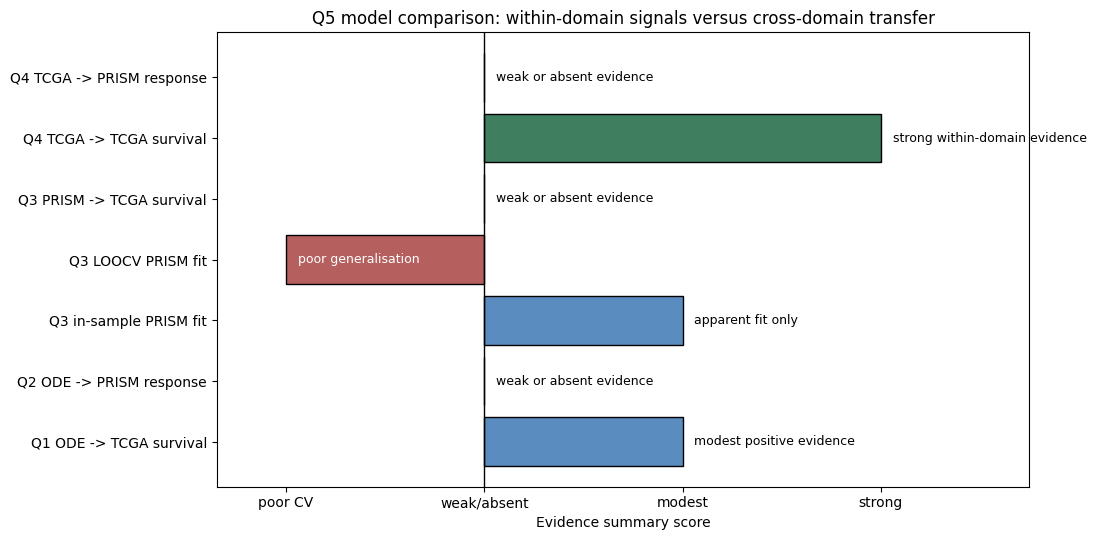

Saved Q5 figure to: figures/q5_model_comparison_summary.png


In [5]:
plot_data = comparison.copy()
plot_data["short_label"] = [
    "Q1 ODE -> TCGA survival",
    "Q2 ODE -> PRISM response",
    "Q3 in-sample PRISM fit",
    "Q3 LOOCV PRISM fit",
    "Q3 PRISM -> TCGA survival",
    "Q4 TCGA -> TCGA survival",
    "Q4 TCGA -> PRISM response",
]

color_map = {
    -1: "#b65f5f",
    0: "#b8b8b8",
    1: "#5b8cc0",
    2: "#3f7f5f",
}

plt.figure(figsize=(11, 5.5))
bars = plt.barh(
    plot_data["short_label"],
    plot_data["evidence_score"],
    color=[color_map[value] for value in plot_data["evidence_score"]],
    edgecolor="black",
)
plt.axvline(0, color="black", linewidth=1)
plt.xlim(-1.35, 2.75)
plt.xlabel("Evidence summary score")
plt.title("Q5 model comparison: within-domain signals versus cross-domain transfer")
plt.xticks([-1, 0, 1, 2], ["poor CV", "weak/absent", "modest", "strong"])

for bar, label in zip(bars, plot_data["evidence_summary"]):
    width = bar.get_width()
    if width < 0:
        x_position = width + 0.06
        ha = "left"
        text_color = "white"
    else:
        x_position = width + 0.06
        ha = "left"
        text_color = "black"
    plt.text(
        x_position,
        bar.get_y() + bar.get_height() / 2,
        label,
        va="center",
        ha=ha,
        fontsize=9,
        color=text_color,
    )

plt.tight_layout()
plt.savefig(figure_path, dpi=200)
plt.show()

print("Saved Q5 figure to:", figure_path.relative_to(project_root))

## Interpretation

Q1 and Q2 give different answers for the same type of mechanistic p53 ODE score. The p53 S46 AUC score showed a modest prognostic association in TCGA-BRCA survival, but it did not predict PRISM doxorubicin sensitivity in the 26 breast cancer cell lines. This suggests that the ODE score may capture general survival-associated p53/DNA-damage biology rather than direct doxorubicin sensitivity.

Q3 and Q4 also show weak cross-domain transfer. The PRISM-derived elastic-net doxorubicin signature had moderate apparent in-sample fit but poor leave-one-out performance and did not transfer to TCGA survival. Conversely, the TCGA-derived Cox survival score was prognostic inside TCGA-BRCA but did not correlate with PRISM doxorubicin sensitivity.

Across Q1-Q4, the strongest signal was within-domain: p53 ODE and Cox-based scores were more informative for TCGA survival than for PRISM drug response. Cross-domain transfer between PRISM doxorubicin sensitivity and TCGA-BRCA survival was weak or absent.